# PD Voice Detection Notebook.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


In [4]:
uci_path = '/kaggle/input/datasets/denismitali/pd-speech-detection-dataset/parkinsons/parkinsons.data'
uci_df = pd.read_csv(uci_path)

print("UCI Dataset Shape:", uci_df.shape)
print("\nFirst 5 rows:")
uci_df.head()

UCI Dataset Shape: (195, 24)

First 5 rows:


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [5]:
train_path = '/kaggle/input/datasets/denismitali/pd-speech-detection-dataset/parkinsonspeechdatasetwithmultipletypesofsoundrecordings/Parkinson_Multiple_Sound_Recording/train_data.txt'
test_path  = '/kaggle/input/datasets/denismitali/pd-speech-detection-dataset/parkinsonspeechdatasetwithmultipletypesofsoundrecordings/Parkinson_Multiple_Sound_Recording/test_data.txt'

sakar_train = pd.read_csv(train_path, header=None)
sakar_test  = pd.read_csv(test_path,  header=None)
sakar_df    = pd.concat([sakar_train, sakar_test], ignore_index=True)

print("Sakar Dataset Shape:", sakar_df.shape)
print("\nFirst 5 rows:")
sakar_df.head()

Sakar Dataset Shape: (1208, 29)

First 5 rows:


,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,1,1.488,0.000090,0.900,0.794,2.699,8.334,0.779,4.517,4.609,...,187.576,160.0,159.0,0.006065,0.000416,0.000,0.0,0.000,23,1.0
1,1,0.728,0.000038,0.353,0.376,1.059,5.864,0.642,2.058,3.180,...,234.505,170.0,169.0,0.005181,0.000403,2.247,0.0,0.000,23,1.0
2,1,1.220,0.000074,0.732,0.670,2.196,8.719,0.875,4.347,5.166,...,211.442,1431.0,1427.0,0.006071,0.000474,10.656,1.0,0.178,23,1.0
3,1,2.502,0.000123,1.156,1.634,3.469,13.513,1.273,5.263,8.771,...,220.230,94.0,92.0,0.004910,0.000320,0.000,0.0,0.000,23,1.0
4,1,3.509,0.000167,1.715,1.539,5.145,9.112,1.040,3.102,4.927,...,225.162,117.0,114.0,0.004757,0.000380,18.182,1.0,13.318,23,1.0


In [6]:
print("=== UCI Dataset Info ===")
print(f"Rows: {uci_df.shape[0]}, Columns: {uci_df.shape[1]}")
print(f"\nMissing values: {uci_df.isnull().sum().sum()}")
print(f"\nClass distribution (status column):")
print(uci_df['status'].value_counts())
print(f"\nPD positive: {uci_df['status'].sum()} ({uci_df['status'].mean()*100:.1f}%)")
print(f"Healthy:     {(uci_df['status']==0).sum()} ({(uci_df['status']==0).mean()*100:.1f}%)")

=== UCI Dataset Info ===
Rows: 195, Columns: 24

Missing values: 0

Class distribution (status column):
status
1    147
0     48
Name: count, dtype: int64

PD positive: 147 (75.4%)
Healthy:     48 (24.6%)


In [7]:
sakar_label_col = sakar_df.columns[-1]

print("=== Sakar Dataset Info ===")
print(f"Rows: {sakar_df.shape[0]}, Columns: {sakar_df.shape[1]}")
print(f"\nMissing values: {sakar_df.isnull().sum().sum()}")
print(f"\nClass distribution (last column):")
print(sakar_df[sakar_label_col].value_counts())

=== Sakar Dataset Info ===
Rows: 1208, Columns: 29

Missing values: 168

Class distribution (last column):
28
1.0    520
0.0    520
Name: count, dtype: int64


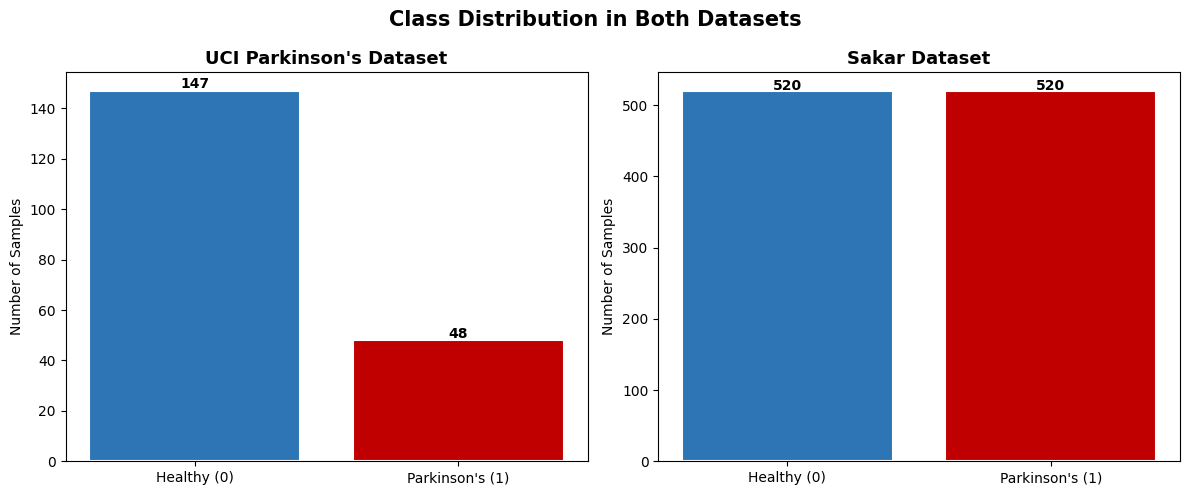

Class distribution plot saved


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Class Distribution in Both Datasets', fontsize=15, fontweight='bold')

# UCI
uci_counts = uci_df['status'].value_counts()
axes[0].bar(['Healthy (0)', 'Parkinson\'s (1)'], uci_counts.values,
            color=['#2E75B6', '#C00000'], edgecolor='white', linewidth=1.5)
axes[0].set_title('UCI Parkinson\'s Dataset', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(uci_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Sakar
sakar_counts = sakar_df[sakar_label_col].value_counts()
axes[1].bar(['Healthy (0)', 'Parkinson\'s (1)'],
            [sakar_counts.get(0, 0), sakar_counts.get(1, 0)],
            color=['#2E75B6', '#C00000'], edgecolor='white', linewidth=1.5)
axes[1].set_title('Sakar Dataset', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Samples')
for i, v in enumerate([sakar_counts.get(0,0), sakar_counts.get(1,0)]):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Class distribution plot saved")

In [9]:
uci_clean = uci_df.drop(columns=['name'])

uci_clean = uci_clean.rename(columns={'status': 'label'})

print("UCI clean shape:", uci_clean.shape)
print("Columns:", list(uci_clean.columns))

UCI clean shape: (195, 23)
Columns: ['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'label', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']


In [10]:
sakar_clean = sakar_df.copy()
sakar_clean.columns = [f'feat_{i}' for i in range(sakar_clean.shape[1])]
sakar_clean = sakar_clean.rename(columns={f'feat_{sakar_clean.shape[1]-1}': 'label'})

sakar_clean = sakar_clean.drop(columns=['feat_0'])

print("Sakar clean shape:", sakar_clean.shape)
print("Label distribution:", sakar_clean['label'].value_counts().to_dict())

Sakar clean shape: (1208, 28)
Label distribution: {1.0: 520, 0.0: 520}


In [11]:
uci_features = [c for c in uci_clean.columns if c != 'label']

print(f"UCI features available: {len(uci_features)}")
print(uci_features)

X_uci = uci_clean[uci_features].values
y_uci = uci_clean['label'].values

X_sakar = sakar_clean.drop(columns=['label']).values
y_sakar = sakar_clean['label'].values

print(f"\nUCI  — X: {X_uci.shape}, y: {y_uci.shape}")
print(f"Sakar — X: {X_sakar.shape}, y: {y_sakar.shape}")

UCI features available: 22
['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP', 'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1', 'spread2', 'D2', 'PPE']

UCI  — X: (195, 22), y: (195,)
Sakar — X: (1208, 27), y: (1208,)


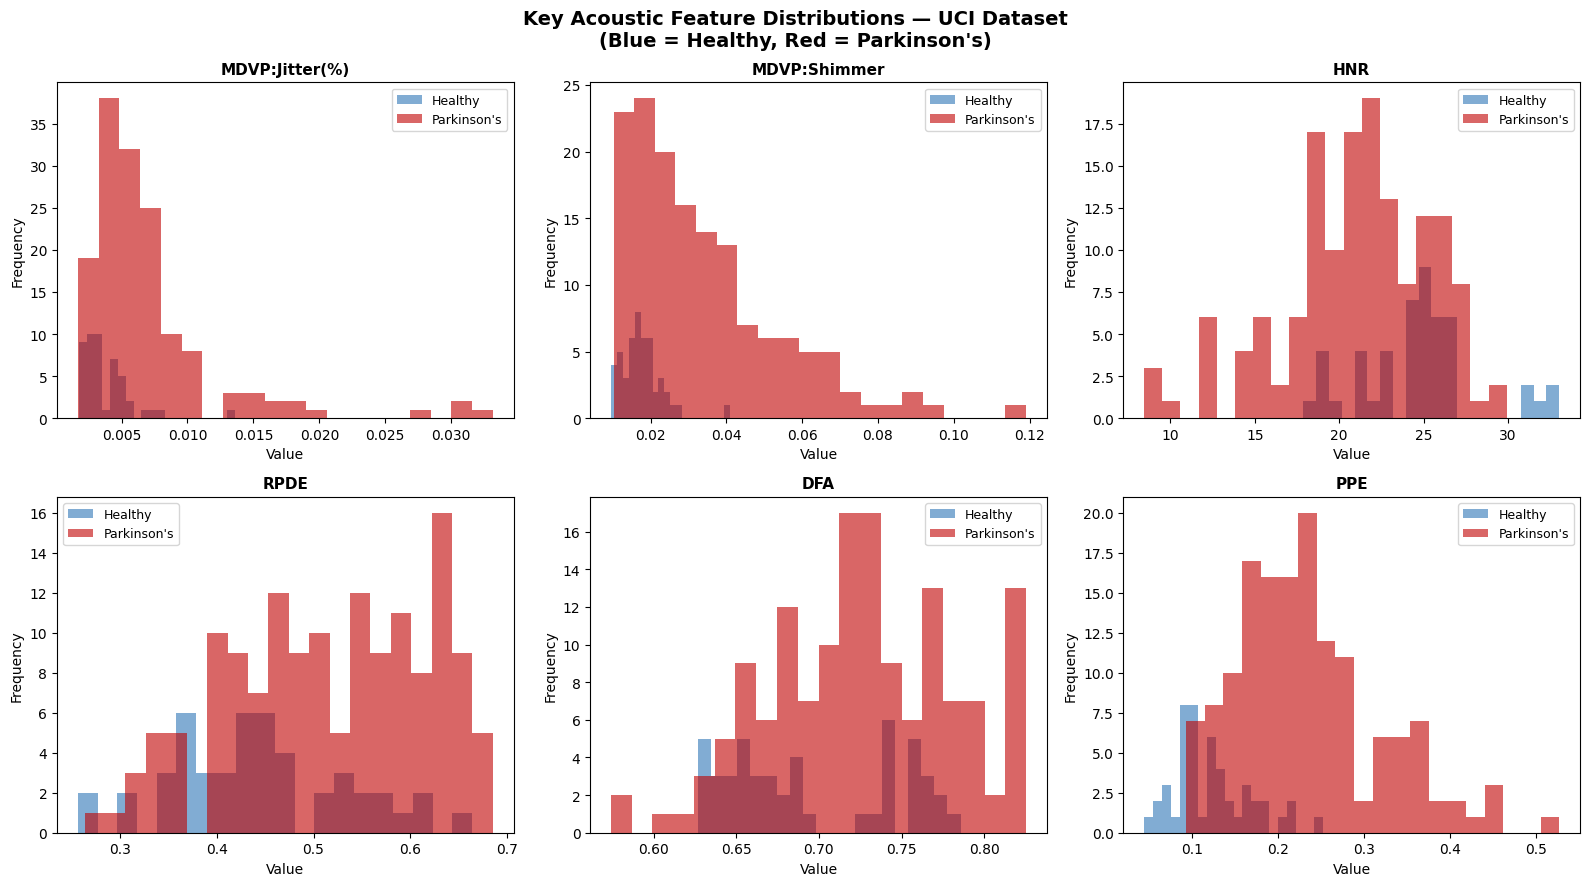

Feature distribution plot saved


In [12]:
key_features = ['MDVP:Jitter(%)', 'MDVP:Shimmer', 'HNR', 'RPDE', 'DFA', 'PPE']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Key Acoustic Feature Distributions — UCI Dataset\n(Blue = Healthy, Red = Parkinson\'s)',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, feat in enumerate(key_features):
    healthy = uci_clean[uci_clean['label'] == 0][feat]
    pd_pos  = uci_clean[uci_clean['label'] == 1][feat]
    axes[idx].hist(healthy, bins=20, alpha=0.6, color='#2E75B6', label='Healthy')
    axes[idx].hist(pd_pos,  bins=20, alpha=0.6, color='#C00000', label='Parkinson\'s')
    axes[idx].set_title(feat, fontsize=11, fontweight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature distribution plot saved")

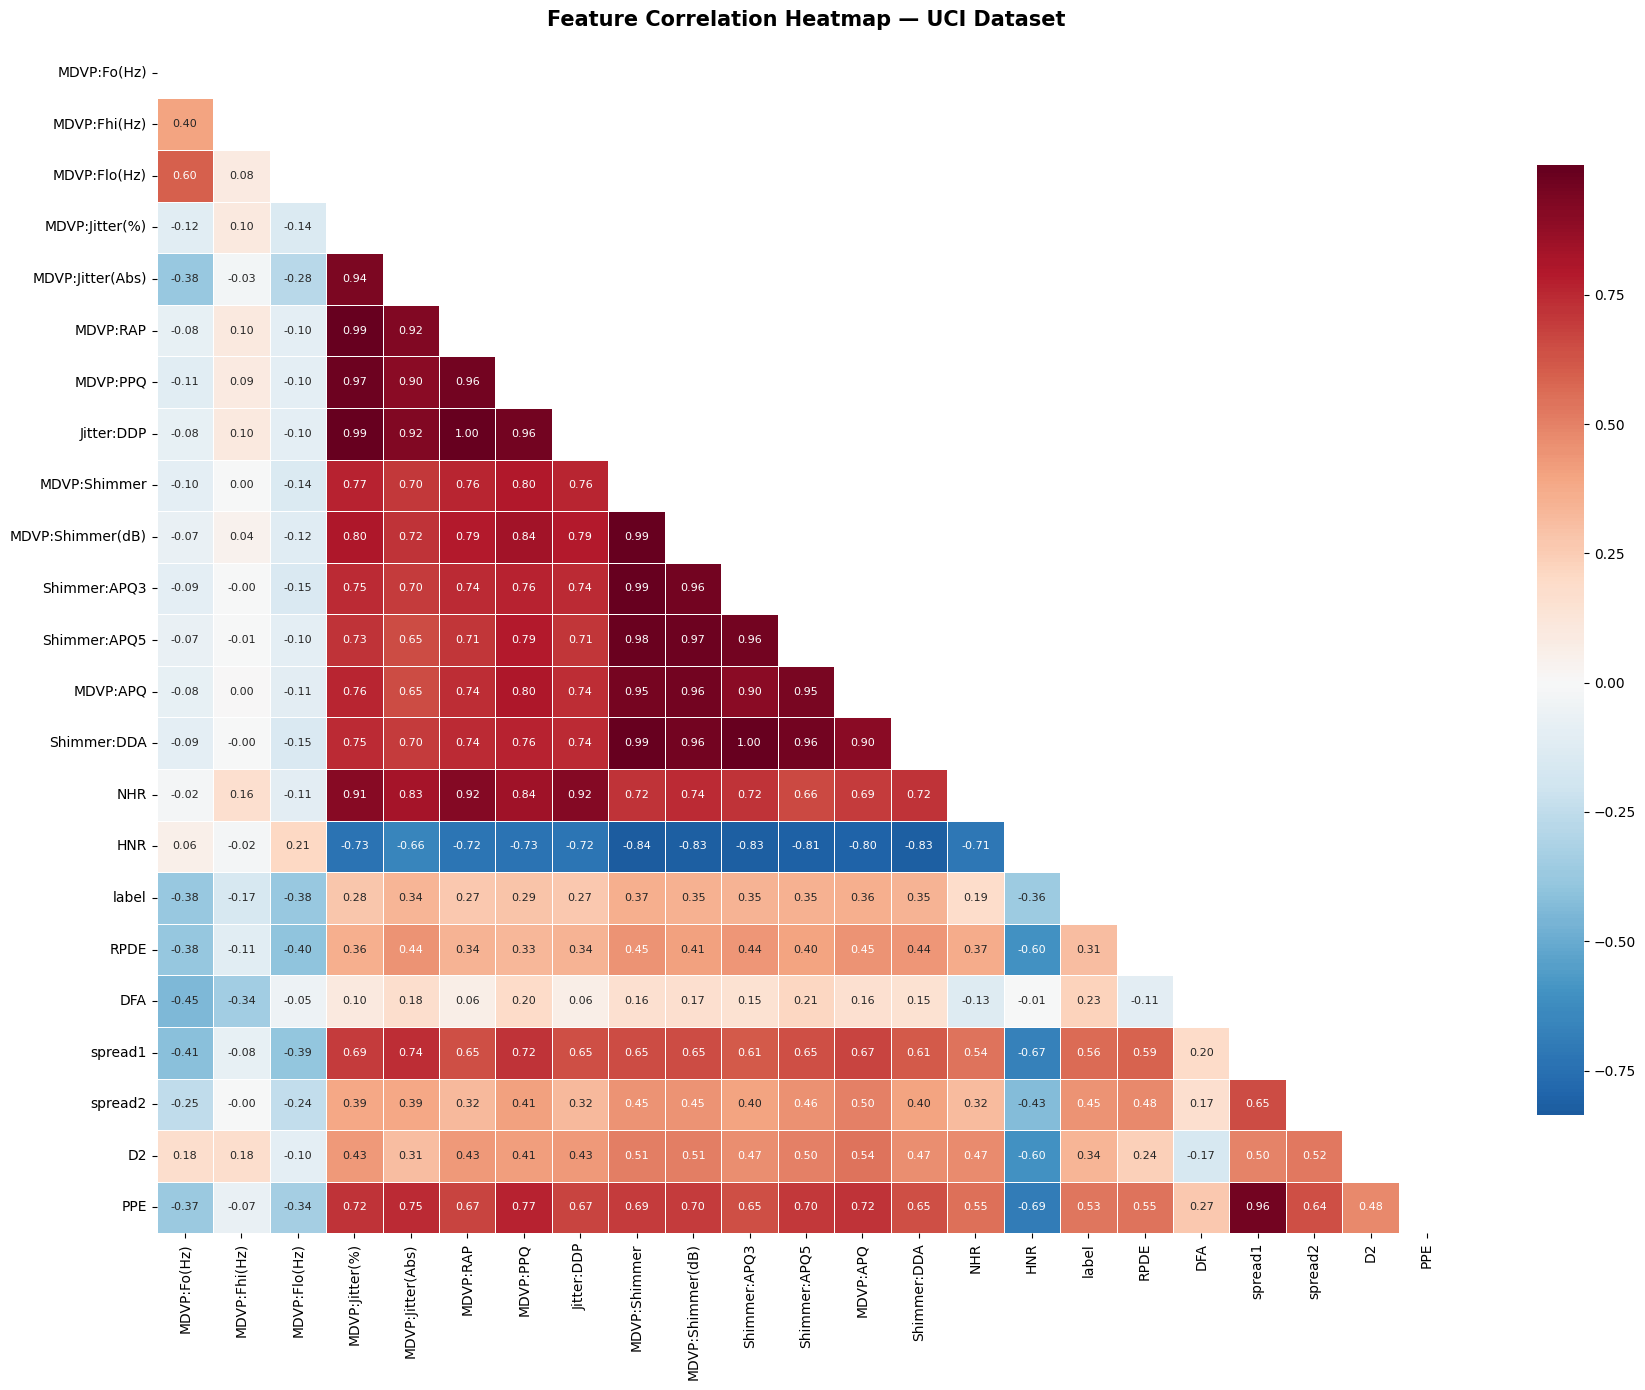

Correlation heatmap saved


In [13]:
plt.figure(figsize=(18, 14))
corr = uci_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap — UCI Dataset', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved")

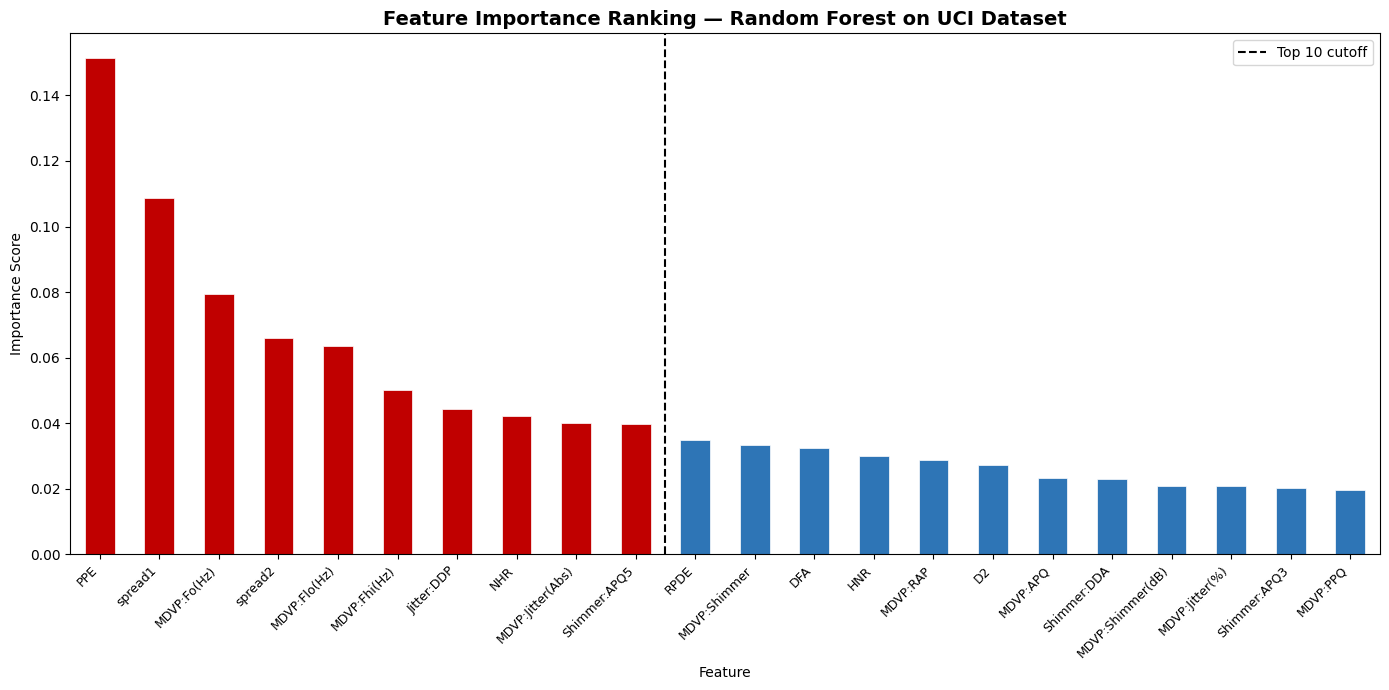

Top 10 features: ['PPE', 'spread1', 'MDVP:Fo(Hz)', 'spread2', 'MDVP:Flo(Hz)', 'MDVP:Fhi(Hz)', 'Jitter:DDP', 'NHR', 'MDVP:Jitter(Abs)', 'Shimmer:APQ5']


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

scaler_temp = StandardScaler()
X_scaled_temp = scaler_temp.fit_transform(X_uci)

rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_scaled_temp, y_uci)

importances = pd.Series(rf_temp.feature_importances_, index=uci_features)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(14, 7))
colors = ['#C00000' if i < 10 else '#2E75B6' for i in range(len(importances))]
importances.plot(kind='bar', color=colors, edgecolor='white', linewidth=0.5)
plt.title('Feature Importance Ranking — Random Forest on UCI Dataset',
          fontsize=14, fontweight='bold')
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.axvline(x=9.5, color='black', linestyle='--', linewidth=1.5, label='Top 10 cutoff')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

top_features = list(importances.head(10).index)
print("Top 10 features:", top_features)

In [15]:
X_selected = uci_clean[top_features].values
y          = uci_clean['label'].values

print(f"Selected feature matrix shape: {X_selected.shape}")
print(f"Label distribution: {dict(zip(*np.unique(y, return_counts=True)))}")
print(f"\nClass imbalance ratio: {y.sum()} PD vs {(y==0).sum()} Healthy")
print("→ SMOTE will be applied during cross-validation to correct this.")

Selected feature matrix shape: (195, 10)
Label distribution: {np.int64(0): np.int64(48), np.int64(1): np.int64(147)}

Class imbalance ratio: 147 PD vs 48 Healthy
→ SMOTE will be applied during cross-validation to correct this.


In [16]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy':  'accuracy',
    'precision': 'precision',
    'recall':    'recall',
    'f1':        'f1',
    'roc_auc':   'roc_auc',
}

models = {
    'Random Forest': ImbPipeline([
        ('smote',   SMOTE(random_state=42)),
        ('scaler',  StandardScaler()),
        ('model',   RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')),
    ]),
    'SVM': ImbPipeline([
        ('smote',   SMOTE(random_state=42)),
        ('scaler',  StandardScaler()),
        ('model',   SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced')),
    ]),
    'Gradient Boosting': ImbPipeline([
        ('smote',   SMOTE(random_state=42)),
        ('scaler',  StandardScaler()),
        ('model',   GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ]),
}

print("Models and pipelines defined")
print("SMOTE applied inside cross-validation folds only — no data leakage")

Models and pipelines defined
SMOTE applied inside cross-validation folds only — no data leakage


In [17]:
results = {}

for name, pipeline in models.items():
    print(f"Training {name}...")
    cv_results = cross_validate(pipeline, X_selected, y, cv=cv,
                                scoring=scoring, return_train_score=False)
    results[name] = {
        'Accuracy':  cv_results['test_accuracy'].mean(),
        'Precision': cv_results['test_precision'].mean(),
        'Recall':    cv_results['test_recall'].mean(),
        'F1 Score':  cv_results['test_f1'].mean(),
        'AUC-ROC':   cv_results['test_roc_auc'].mean(),
    }
    print(f" Recall: {results[name]['Recall']:.4f} | F1: {results[name]['F1 Score']:.4f} | AUC: {results[name]['AUC-ROC']:.4f}")

print("\nAll models trained")

Training Random Forest...
 Recall: 0.9455 | F1: 0.9519 | AUC: 0.9648
Training SVM...
 Recall: 0.8570 | F1: 0.8954 | AUC: 0.9342
Training Gradient Boosting...
 Recall: 0.9386 | F1: 0.9448 | AUC: 0.9703

All models trained


In [18]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values('Recall', ascending=False)

print("=== Model Performance Comparison (5-Fold Cross-Validation) ===\n")
print(results_df.to_string())

best_model_name = results_df['Recall'].idxmax()
print(f"\n Best model by Recall: {best_model_name}")
print(f"  Recall:   {results_df.loc[best_model_name, 'Recall']:.4f}")
print(f"  F1 Score: {results_df.loc[best_model_name, 'F1 Score']:.4f}")
print(f"  AUC-ROC:  {results_df.loc[best_model_name, 'AUC-ROC']:.4f}")

=== Model Performance Comparison (5-Fold Cross-Validation) ===

                   Accuracy  Precision  Recall  F1 Score  AUC-ROC
Random Forest        0.9282     0.9591  0.9455    0.9519   0.9648
Gradient Boosting    0.9179     0.9521  0.9386    0.9448   0.9703
SVM                  0.8513     0.9437  0.8570    0.8954   0.9342

 Best model by Recall: Random Forest
  Recall:   0.9455
  F1 Score: 0.9519
  AUC-ROC:  0.9648


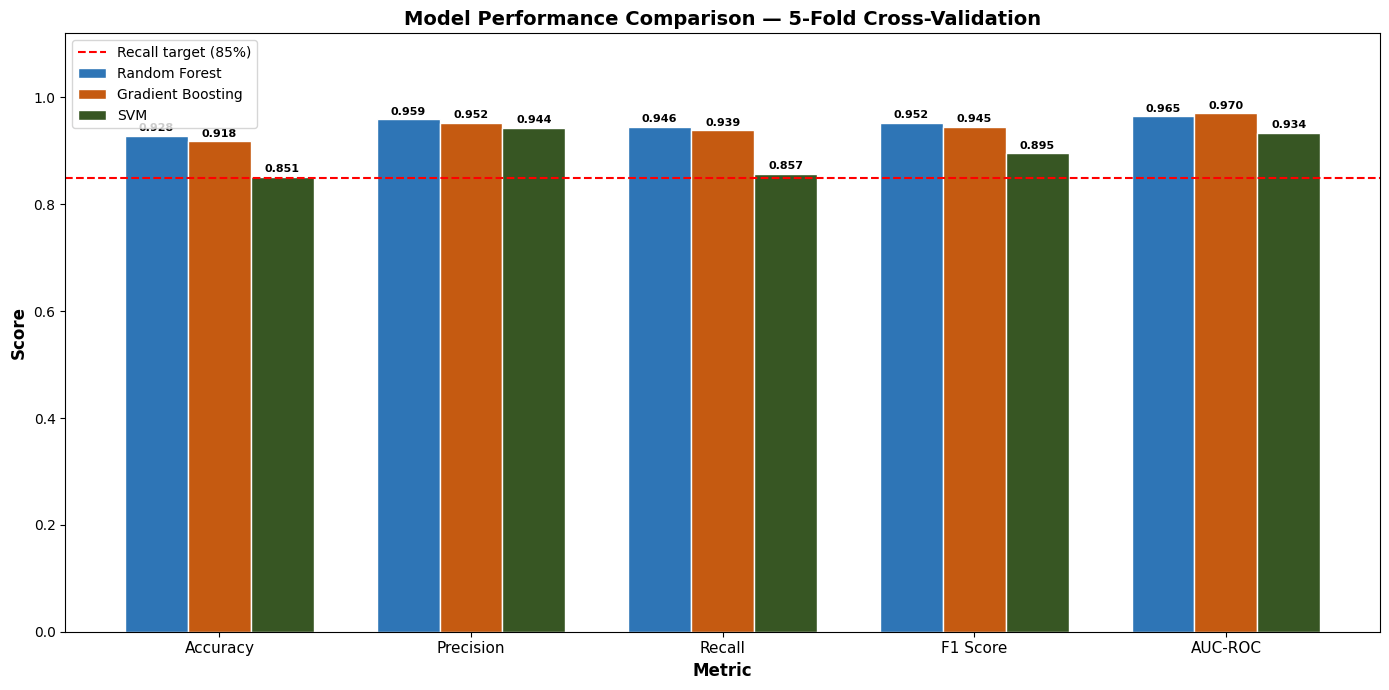

Model comparison chart saved


In [19]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
x = np.arange(len(metrics))
width = 0.25
colors = ['#2E75B6', '#C55A11', '#375623']

fig, ax = plt.subplots(figsize=(14, 7))
for i, (name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metrics],
                  width, label=name, color=colors[i],
                  edgecolor='white', linewidth=1)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison — 5-Fold Cross-Validation',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.axhline(y=0.85, color='red', linestyle='--', linewidth=1.5, label='Recall target (85%)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison chart saved")

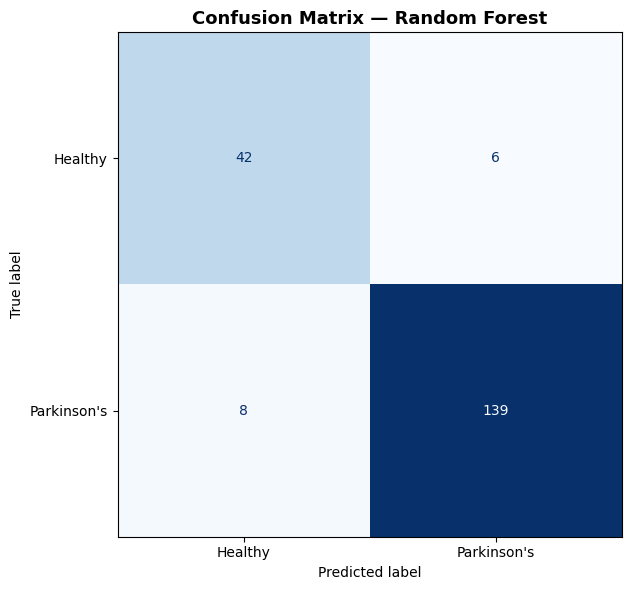


Classification Report:
              precision    recall  f1-score   support

     Healthy       0.84      0.88      0.86        48
 Parkinson's       0.96      0.95      0.95       147

    accuracy                           0.93       195
   macro avg       0.90      0.91      0.90       195
weighted avg       0.93      0.93      0.93       195



In [20]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

best_pipeline = models[best_model_name]
y_pred = cross_val_predict(best_pipeline, X_selected, y, cv=cv)

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Healthy', "Parkinson's"])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_model_name}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=['Healthy', "Parkinson's"]))

In [21]:
print(f"Tuning {best_model_name}...")

if best_model_name == 'Random Forest':
    param_grid = {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth':    [None, 10, 20],
        'model__min_samples_split': [2, 5],
    }
elif best_model_name == 'SVM':
    param_grid = {
        'model__C':     [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto'],
    }
else:
    param_grid = {
        'model__n_estimators':  [100, 200, 300],
        'model__learning_rate': [0.05, 0.1, 0.2],
        'model__max_depth':     [3, 5, 7],
    }

grid_search = GridSearchCV(
    models[best_model_name], param_grid,
    cv=cv, scoring='recall', n_jobs=-1, verbose=1
)
grid_search.fit(X_selected, y)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best recall:     {grid_search.best_score_:.4f}")

best_tuned_model = grid_search.best_estimator_

Tuning Random Forest...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best recall:     0.9591


In [22]:
y_pred_tuned = cross_val_predict(best_tuned_model, X_selected, y, cv=cv)

print("=== Final Tuned Model Performance ===")
print(f"Accuracy:  {accuracy_score(y, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y, y_pred_tuned):.4f}")
print(f"F1 Score:  {f1_score(y, y_pred_tuned):.4f}")

# AUC-ROC needs probabilities
y_proba_tuned = cross_val_predict(best_tuned_model, X_selected, y,
                                   cv=cv, method='predict_proba')[:,1]
print(f"AUC-ROC:   {roc_auc_score(y, y_proba_tuned):.4f}")

print("\nClassification Report:")
print(classification_report(y, y_pred_tuned, target_names=['Healthy', "Parkinson's"]))

=== Final Tuned Model Performance ===
Accuracy:  0.9385
Precision: 0.9592
Recall:    0.9592
F1 Score:  0.9592
AUC-ROC:   0.9619

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.88      0.88      0.88        48
 Parkinson's       0.96      0.96      0.96       147

    accuracy                           0.94       195
   macro avg       0.92      0.92      0.92       195
weighted avg       0.94      0.94      0.94       195



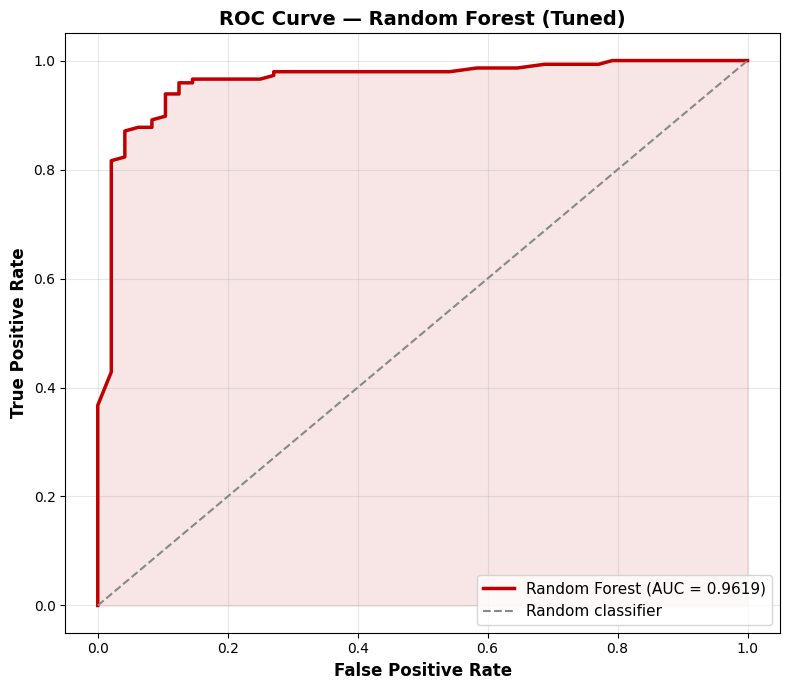

ROC curve saved  |  AUC = 0.9619


In [23]:
from sklearn.metrics import RocCurveDisplay, roc_curve, auc

fpr, tpr, _ = roc_curve(y, y_proba_tuned)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='#C00000', lw=2.5,
         label=f'{best_model_name} (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='#888888', lw=1.5, linestyle='--', label='Random classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#C00000')
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title(f'ROC Curve — {best_model_name} (Tuned)',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"ROC curve saved  |  AUC = {roc_auc:.4f}")

In [24]:
print("Top features selected for the model:")
for i, f in enumerate(top_features, 1):
    print(f"  {i}. {f}")

with open('top_features.txt', 'w') as f:
    f.write('\n'.join(top_features))
print("\nTop features list saved to top_features.txt")

Top features selected for the model:
  1. PPE
  2. spread1
  3. MDVP:Fo(Hz)
  4. spread2
  5. MDVP:Flo(Hz)
  6. MDVP:Fhi(Hz)
  7. Jitter:DDP
  8. NHR
  9. MDVP:Jitter(Abs)
  10. Shimmer:APQ5

Top features list saved to top_features.txt


In [25]:
print("Training final model on full dataset...")

final_pipeline = best_tuned_model
final_pipeline.fit(X_selected, y)

joblib.dump(final_pipeline, 'parkisense_model.pkl')
print("Model saved as parkisense_model.pkl")

joblib.dump(top_features, 'feature_names.pkl')
print("Feature names saved as feature_names.pkl")

test_pred = final_pipeline.predict(X_selected[:5])
print(f"\nSanity check — first 5 predictions: {test_pred}")
print(f"Actual labels:                        {y[:5]}")

Training final model on full dataset...
Model saved as parkisense_model.pkl
Feature names saved as feature_names.pkl

Sanity check — first 5 predictions: [1 1 1 1 1]
Actual labels:                        [1 1 1 1 1]


In [26]:
print("=" * 55)
print("         ParkiSense ML Pipeline — Summary")
print("=" * 55)
print(f"\n  Datasets used:")
print(f"    UCI Parkinson's Dataset  — {X_uci.shape[0]} samples")
print(f"    Sakar Dataset            — {X_sakar.shape[0]} samples")
print(f"\n  Features selected: {len(top_features)}")
print(f"  Features: {top_features}")
print(f"\n  Best model: {best_model_name}")
print(f"  Best params: {grid_search.best_params_}")
print(f"\n  Final Performance (5-Fold CV):")
print(f"    Accuracy:  {accuracy_score(y, y_pred_tuned):.4f}")
print(f"    Precision: {precision_score(y, y_pred_tuned):.4f}")
print(f"    Recall:    {recall_score(y, y_pred_tuned):.4f}")
print(f"    F1 Score:  {f1_score(y, y_pred_tuned):.4f}")
print(f"    AUC-ROC:   {roc_auc_score(y, y_proba_tuned):.4f}")
print(f"\n  Output files:")
print(f"    parkisense_model.pkl  — trained model")
print(f"    feature_names.pkl     — feature list")
print(f"\n  Status: Ready for FastAPI deployment ✓")
print("=" * 55)

         ParkiSense ML Pipeline — Summary

  Datasets used:
    UCI Parkinson's Dataset  — 195 samples
    Sakar Dataset            — 1208 samples

  Features selected: 10
  Features: ['PPE', 'spread1', 'MDVP:Fo(Hz)', 'spread2', 'MDVP:Flo(Hz)', 'MDVP:Fhi(Hz)', 'Jitter:DDP', 'NHR', 'MDVP:Jitter(Abs)', 'Shimmer:APQ5']

  Best model: Random Forest
  Best params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}

  Final Performance (5-Fold CV):
    Accuracy:  0.9385
    Precision: 0.9592
    Recall:    0.9592
    F1 Score:  0.9592
    AUC-ROC:   0.9619

  Output files:
    parkisense_model.pkl  — trained model
    feature_names.pkl     — feature list

  Status: Ready for FastAPI deployment ✓
